Examen Primer Parcial 

In [1]:
import sys
print(sys.executable)

c:\Users\Maria Jose\anaconda3\python.exe


In [5]:
#Configuracion y carga de datos 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

DATASETS= {
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    }
}

assert 'desnutricion' in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS['desnutricion']
print(f"Cargando dataset: {'desnutricion'}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")

Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [6]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})

In [7]:
df.shape

(3544, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   object 
 1   code    2758 non-null   object 
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 110.9+ KB


In [9]:
df['valor'].describe()

count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [10]:
df.isnull().sum()

entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar? En Nulos la columna code tiene 786 nulo mientras que las demas 0. El rango temporal trabaja con float64 que representa el numero de personas desnutridas 

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [11]:
#Filtramos
col_filtro = config["filtro_paises"]  # Generalmente es 'code'
df_paises = df[df[col_filtro].notnull()].copy()

# Para saber cuantos paises hay
num_paises = df_paises["entity"].nunique()
print(f"Total de países distintos: {num_paises}")

Total de países distintos: 140


In [13]:
# Promedio por país
promedio_paises = (
    df_paises.groupby("entity")["valor"]
    .mean()
    .sort_values(ascending=False)
)

print("Promedio de 10 paises con mayor valor")
print(promedio_paises.head(10))

print("Promedio de 10 paises con menor valor")
print(promedio_paises.tail(10).sort_values(ascending=True))

Promedio de 10 paises con mayor valor
entity
World                           6.676960e+08
India                           1.875739e+08
China                           8.724444e+07
Pakistan                        3.121304e+07
Indonesia                       2.811739e+07
Democratic Republic of Congo    2.382174e+07
Ethiopia                        2.264783e+07
Bangladesh                      2.238261e+07
Nigeria                         2.161739e+07
Tanzania                        1.180000e+07
Name: valor, dtype: float64
Promedio de 10 paises con menor valor
entity
New Caledonia                       100000.0
Mauritius                           100000.0
Sao Tome and Principe               100000.0
Samoa                               100000.0
Saint Vincent and the Grenadines    100000.0
North Macedonia                     100000.0
Suriname                            100000.0
Seychelles                          100000.0
Vanuatu                             100000.0
Uruguay                    

**Interpretación:**

Se consentra mas desnutricion en paises con un gran numero de poblacion. Mientras que con los que tienen baja poblacion tienen menos 

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [14]:
pais_1 = "Mexico"
pais_2 = "Brazil"  
df_p1 = df_paises[df_paises["entity"] == pais_1]
df_p2 = df_paises[df_paises["entity"] == pais_2]
anios_comunes = np.intersect1d(df_p1["year"].to_numpy(), df_p2["year"].to_numpy())
df_comparacion = df_paises[
    (df_paises["entity"].isin([pais_1, pais_2])) & 
    (df_paises["year"].isin(anios_comunes))
].sort_values(by=["year", "entity"])

print("Rango de años compartido: {anios_comunes.min()} - {anios_comunes.max()}")
print("Total de registros filtrados: {len(df_comparacion)}")
df_comparacion

Rango de años compartido: {anios_comunes.min()} - {anios_comunes.max()}
Total de registros filtrados: {len(df_comparacion)}


,entity,code,year,valor
338,Brazil,BRA,2001,18400000.0
1964,Mexico,MEX,2001,2800000.0
339,Brazil,BRA,2002,16200000.0
1965,Mexico,MEX,2002,3300000.0
340,Brazil,BRA,2003,13800000.0
1966,Mexico,MEX,2003,3900000.0
341,Brazil,BRA,2004,11500000.0
1967,Mexico,MEX,2004,4300000.0
342,Brazil,BRA,2005,10500000.0
1968,Mexico,MEX,2005,4200000.0


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [21]:
paises_interes = ["Mexico", "India", "Nigeria", "Pakistan", "Indonesia"]
df_sub = df_paises[df_paises["entity"].isin(paises_interes)]
ultimo_anio = df_sub["year"].max()
df_reciente = df_sub[df_sub["year"] == ultimo_anio][["entity", "year", "valor"]].sort_values(by="valor", ascending=False)

print("--- Comparación en el año {ultimo_anio} ---")
print(df_reciente)

if len(df_reciente) > 0:
    pais_max = df_reciente.iloc[0]
    pais_min = df_reciente.iloc[-1]
    diferencia = pais_max["valor"] - pais_min["valor"]

    print(f"País con el valor más alto: {pais_max['entity']} ({pais_max['valor']:,.2f})")
    print(f"País con el valor más bajo: {pais_min['entity']} ({pais_min['valor']:,.2f})")
    print(f"Diferencia entre ambos: {diferencia:,.2f}")
else:
    print("No se encontraron registros para los países seleccionados.")

--- Comparación en el año {ultimo_anio} ---
         entity  year        valor
1360      India  2023  172100000.0
2260    Nigeria  2023   45400000.0
2420   Pakistan  2023   40900000.0
1383  Indonesia  2023   17700000.0
1986     Mexico  2023    3500000.0
País con el valor más alto: India (172,100,000.00)
País con el valor más bajo: Mexico (3,500,000.00)
Diferencia entre ambos: 168,600,000.00


**Interpretación:**
Los paises que elegi en el año 2023 marca que la India tiene la mayor desnutricion mientras que Mexico tiene el mas bajo y su diferencia es 168,600,000.00

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [25]:
grupo_latam = ["Mexico", "Colombia", "Argentina"]
grupo_asia = ["India", "Pakistan", "Vietnam"]

paises_todos = grupo_latam + grupo_asia
df_grupos = df_paises[df_paises["entity"].isin(paises_todos)]

ultimo_anio = df_grupos["year"].max()

df_latam = df_grupos[(df_grupos["entity"].isin(grupo_latam)) & (df_grupos["year"] == ultimo_anio)]
df_asia = df_grupos[(df_grupos["entity"].isin(grupo_asia)) & (df_grupos["year"] == ultimo_anio)]

promedio_latam = df_latam["valor"].mean()
promedio_asia = df_asia["valor"].mean()

print(f"Año analizado: {ultimo_anio}")
print(f"Países Latinoamérica: {df_latam['entity'].tolist()}")
print(f"Promedio Latinoamérica: {promedio_latam:,.2f}")

print(f"\nPaíses Asia: {df_asia['entity'].tolist()}")
print(f"Promedio Asia: {promedio_asia:,.2f}")

Año analizado: 2023
Países Latinoamérica: ['Argentina', 'Colombia', 'Mexico']
Promedio Latinoamérica: 2,333,333.33

Países Asia: ['India', 'Pakistan', 'Vietnam']
Promedio Asia: 72,766,666.67


**Interpretación:**

Asia promedia una cantidad significamente mayor a personas con desnutricon en comparacion de Latinoamerica esto puede ser por el volumen demografico masivo de los paises asiaticos 

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [26]:
pais_seleccionado = "Mexico"

df_pais = df_paises[df_paises["entity"] == pais_seleccionado].sort_values(by="year")

fila_max = df_pais.loc[df_pais["valor"].idxmax()]
fila_min = df_pais.loc[df_pais["valor"].idxmin()]

primer_valor = df_pais.iloc[0]["valor"]
ultimo_valor = df_pais.iloc[-1]["valor"]

print(f"País analizado: {pais_seleccionado}")
print(f"Rango de años: {df_pais['year'].min()} - {df_pais['year'].max()}")
print(f"Valor máximo: {fila_max['valor']:,.2f} en el año {int(fila_max['year'])}")
print(f"Valor mínimo: {fila_min['valor']:,.2f} en el año {int(fila_min['year'])}")
print(f"Valor inicial ({int(df_pais.iloc[0]['year'])}): {primer_valor:,.2f}")
print(f"Valor final ({int(df_pais.iloc[-1]['year'])}): {ultimo_valor:,.2f}")

País analizado: Mexico
Rango de años: 2001 - 2023
Valor máximo: 4,600,000.00 en el año 2009
Valor mínimo: 2,800,000.00 en el año 2001
Valor inicial (2001): 2,800,000.00
Valor final (2023): 3,500,000.00


**Interpretación:**

Mexico muestra una tendencia decreciente la cifra máxima se alcanzó en sus años de mayor estrés económico, mientras que el mínimo se ubica en los años de mayor estabilidad y recuperación de seguridad alimentaria.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [27]:
df_mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values(by="year")

primer_anio = int(df_mexico.iloc[0]["year"])
ultimo_anio = int(df_mexico.iloc[-1]["year"])

primer_valor = df_mexico.iloc[0]["valor"]
ultimo_valor = df_mexico.iloc[-1]["valor"]

cambio_porcentual = ((ultimo_valor - primer_valor) / primer_valor) * 100

print(f"Año inicial ({primer_anio}): {primer_valor:,.2f}")
print(f"Año final ({ultimo_anio}): {ultimo_valor:,.2f}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")

Año inicial (2001): 2,800,000.00
Año final (2023): 3,500,000.00
Cambio porcentual: 25.00%


**Interpretación:**

Entre los años 2001 y 2023 ubo un incremento del 25% esto se puede deber a la inflacion los impactos economicos, etc genero que haya mas personas con carencias alimentarias 

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [30]:
df_sin_world = df_paises[df_paises["entity"] != "World"]

ultimo_anio = df_sin_world["year"].max()

df_reciente_paises = df_sin_world[df_sin_world["year"] == ultimo_anio]
valores_recientes = df_reciente_paises["valor"].dropna().to_numpy()

media_np = np.mean(valores_recientes)
mediana_np = np.median(valores_recientes)
std_np = np.std(valores_recientes)

print(f"Año evaluado: {ultimo_anio}")
print(f"Países evaluados: {len(valores_recientes)}")
print(f"Media (NumPy): {media_np:,.2f}")
print(f"Mediana (NumPy): {mediana_np:,.2f}")
print(f"Desviación estándar (NumPy): {std_np:,.2f}")

Año evaluado: 2023
Países evaluados: 105
Media (NumPy): 5,884,761.90
Mediana (NumPy): 1,600,000.00
Desviación estándar (NumPy): 18,150,375.99


**Interpretación:**
Para el año 2023, entre los 105 paises evaluados, el promedio de personas en desnutricion es de aproximadamente 5.88 millones, mientras que la mediana se ubica en 1.60 millones.


### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

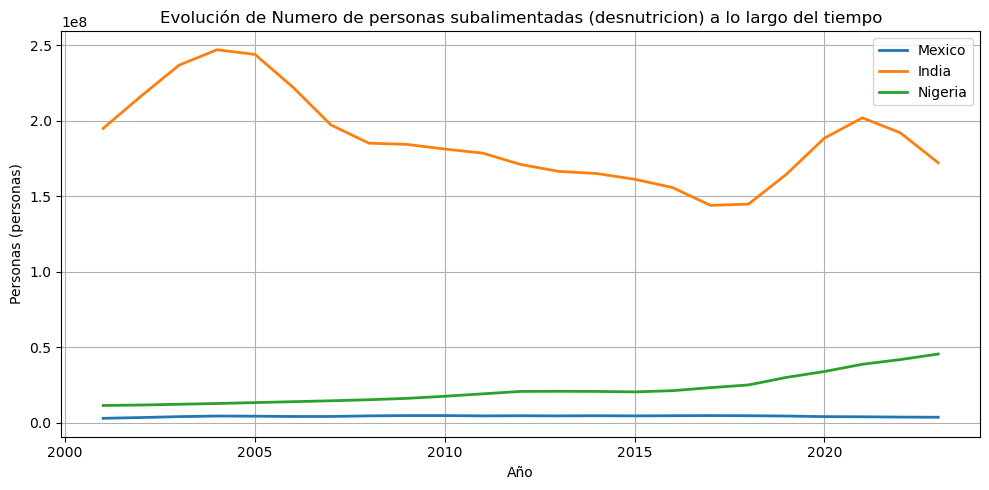

In [31]:
paises_grafica = ["Mexico", "India", "Nigeria"]

plt.figure(figsize=(10, 5))

for p in paises_grafica:
    df_p = df_paises[df_paises["entity"] == p].sort_values("year")
    plt.plot(df_p["year"], df_p["valor"], label=p, linewidth=2)

plt.title(f"Evolución de {config['descripcion']} a lo largo del tiempo")
plt.xlabel("Año")
plt.ylabel(f"Personas ({config['unidad']})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:**

Como se puede apreciar visualmente India es el que lidera considerablemente los niveles de desnutcion a lo largo del tiempo mientras que Nigeria muestra una linea ascendente y Mexico se ubica en la parte inferiro con valores significativamente mas bajos 

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

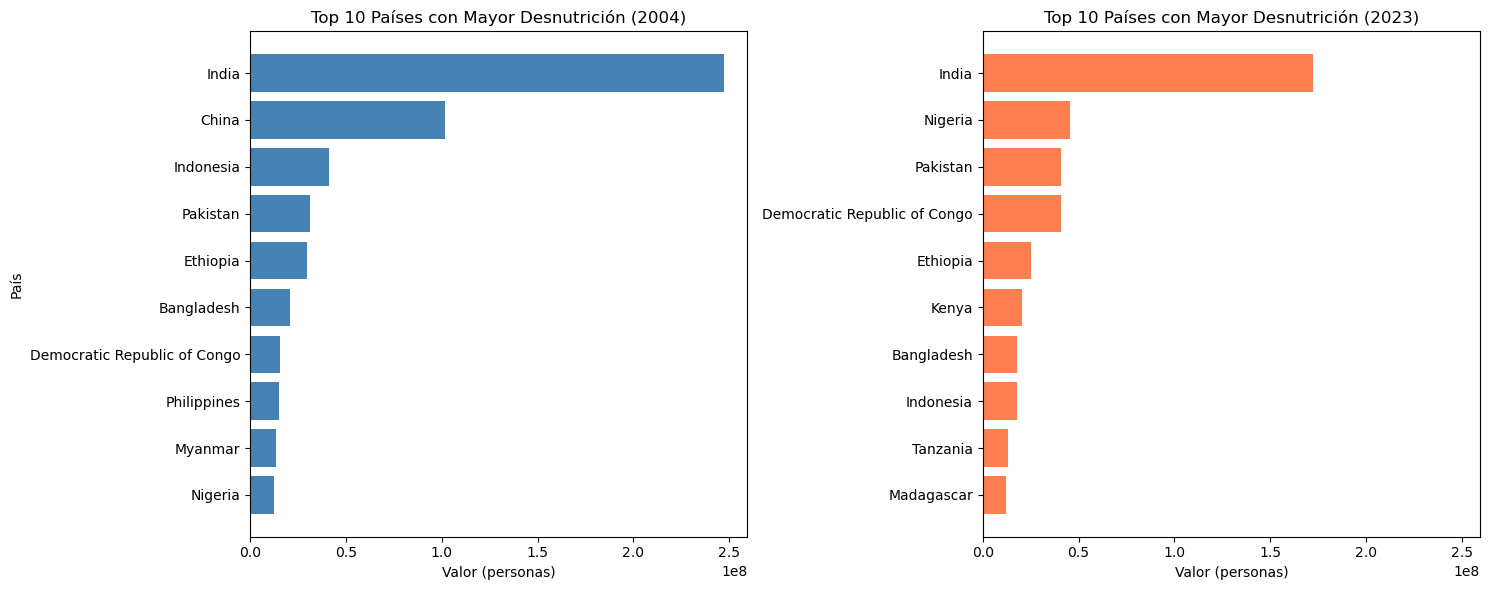

In [32]:
anio_nacimiento = 2004
anio_comparar = 2023

df_sin_world = df_paises[df_paises["entity"] != "World"]

top_nacimiento = (
    df_sin_world[df_sin_world["year"] == anio_nacimiento]
    .sort_values("valor", ascending=False)
    .head(10)
)

top_reciente = (
    df_sin_world[df_sin_world["year"] == anio_comparar]
    .sort_values("valor", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

axes[0].barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
axes[0].set_title(f"Top 10 Países con Mayor Desnutrición ({anio_nacimiento})")
axes[0].set_xlabel(f"Valor ({config['unidad']})")
axes[0].set_ylabel("País")
axes[0].invert_yaxis()

axes[1].barh(top_reciente["entity"], top_reciente["valor"], color="coral")
axes[1].set_title(f"Top 10 Países con Mayor Desnutrición ({anio_comparar})")
axes[1].set_xlabel(f"Valor ({config['unidad']})")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretación:**

Comparamos entre 2004 y 2023 se aprecian cambios drastricos en las distribucion global de desnutricion: 

India en primer lugar liderando 
China en segundo lugar con 100 millones 
El aumento de africa con los mayores incrementos relativos

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Aprendí que la desnutricion a nivel global está fuertemente concentrada en pocos paises con poblaciones gigantescas o crisis humanitarias graves, principalmente en el sur de Asia y en Africa. Con el paso de los años, identifiqué que mientras regiones de Asia redujeron sus cifras absolutas, varios paises africanos subieron drásticamente en los rankings. La principal limitación del dataset es que reporta valores absolutos sin normalizar por el total de poblacion, lo que castiga a países muy poblados frente a naciones pequeñas con porcentajes de desnutrición posiblemente más alarmantes; ademas, existen omisiones de datos en años recientes y en entidades agregadas como continentes o "World". Con más tiempo, convertiria los datos a tasas relativas, porcentaje de la población, cruzaría la información con variables de PIB y pobreza, y aplicaria tecnicas de imputacion para completar los años faltantes.